Big-O prediction


In [1]:
import os
if not os.path.exists("features.py"):
    !git clone -q https://github.com/raunaktiwari1729/BIGO
    %cd BIGO
!pip install -q xgboost

/content/BIGO


In [2]:
import numpy as np, pandas as pd, warnings, pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold, GroupKFold, KFold, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report
import xgboost as xgb
from features import hand_features, extra_features, FEATURE_NAMES, EXTRA_NAMES
warnings.filterwarnings("ignore")
os.makedirs("results", exist_ok=True)

In [3]:
df = pd.read_json("java_data.jsonl", lines=True)
X = np.array([hand_features(c) + extra_features(c) for c in df.src], dtype=float)
names = FEATURE_NAMES + EXTRA_NAMES
le = LabelEncoder()
y = le.fit_transform(df.complexity)
g = df.problem.values
print(X.shape, len(set(g)), "problems")

(4900, 21) 258 problems


In [4]:
prob_folds = list(StratifiedGroupKFold(5, shuffle=True, random_state=42).split(X, y, g))
rand_folds = list(StratifiedKFold(5, shuffle=True, random_state=42).split(X, y))

def cv_acc(model, folds, X=X):
    accs = []
    for tr, te in folds:
        model.fit(X[tr], y[tr])
        accs.append((model.predict(X[te]) == y[te]).mean())
    return np.mean(accs) * 100, np.std(accs) * 100

 random split vs problem split

In [5]:
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=0),
    "Random Forest": RandomForestClassifier(300, random_state=0, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(300, random_state=0, n_jobs=-1),
    "kNN": make_pipeline(StandardScaler(), KNeighborsClassifier(15)),
    "Naive Bayes": GaussianNB(),
    "SVM (RBF)": make_pipeline(StandardScaler(), SVC()),
    "MLP": make_pipeline(StandardScaler(), MLPClassifier((64, 32), max_iter=300, random_state=0)),
    "Gradient Boosting": GradientBoostingClassifier(random_state=0),
    "XGBoost": xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1, n_jobs=-1),
}
rows = []
for name, m in models.items():
    r, _ = cv_acc(m, rand_folds)
    p, s = cv_acc(m, prob_folds)
    rows.append([name, round(float(r), 1), round(float(p), 1), round(float(s), 1)])
    print(name, rows[-1][1:])
res = pd.DataFrame(rows, columns=["model", "random_split", "problem_split", "std"]).sort_values("problem_split", ascending=False)
res.to_csv("results/model_comparison.csv", index=False)
res

Logistic Regression [60.6, 50.5, 7.7]
Decision Tree [63.3, 50.1, 5.2]
Random Forest [71.5, 54.2, 5.8]
Extra Trees [71.0, 54.7, 6.1]
kNN [63.1, 51.3, 6.1]
Naive Bayes [35.4, 32.6, 7.5]
SVM (RBF) [64.2, 51.7, 7.2]
MLP [68.3, 52.9, 6.4]
Gradient Boosting [68.4, 54.9, 5.3]
XGBoost [70.3, 53.7, 5.1]


,model,random_split,problem_split,std
8,Gradient Boosting,68.4,54.9,5.3
3,Extra Trees,71.0,54.7,6.1
2,Random Forest,71.5,54.2,5.8
9,XGBoost,70.3,53.7,5.1
7,MLP,68.3,52.9,6.4
6,SVM (RBF),64.2,51.7,7.2
4,kNN,63.1,51.3,6.1
0,Logistic Regression,60.6,50.5,7.7
1,Decision Tree,63.3,50.1,5.2
5,Naive Bayes,35.4,32.6,7.5


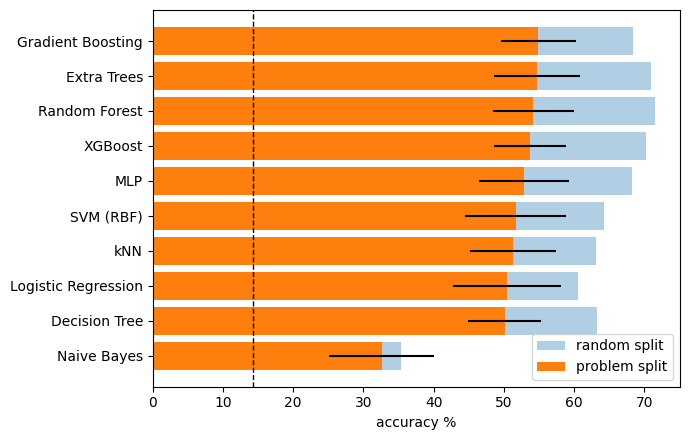

In [6]:
r = res.sort_values("problem_split")
plt.figure(figsize=(7, 4.5))
plt.barh(r.model, r.random_split, alpha=0.35, label="random split")
plt.barh(r.model, r.problem_split, xerr=r["std"], label="problem split")
plt.axvline(100 / 7, color="k", ls="--", lw=1)
plt.xlabel("accuracy %")
plt.legend()
plt.tight_layout()
plt.savefig("results/model_comparison.png", dpi=150)
plt.show()

Tuning (nested CV, so the tuned score is not inflated)

In [7]:
spaces = {
    "Random Forest": (RandomForestClassifier(random_state=0, n_jobs=-1),
        dict(n_estimators=[200, 400], max_depth=[6, 10, 15, None], min_samples_leaf=[1, 3, 5], max_features=["sqrt", 0.5])),
    "Extra Trees": (ExtraTreesClassifier(random_state=0, n_jobs=-1),
        dict(n_estimators=[200, 400], max_depth=[6, 10, 15, None], min_samples_leaf=[1, 3, 5], max_features=["sqrt", 0.5])),
    "XGBoost": (xgb.XGBClassifier(n_jobs=-1),
        dict(n_estimators=[100, 200, 400], max_depth=[2, 3, 4, 6], learning_rate=[0.03, 0.05, 0.1],
             subsample=[0.7, 1], colsample_bytree=[0.6, 1], min_child_weight=[1, 5, 10])),
}
tuned = {}
for name, (m, sp) in spaces.items():
    accs = []
    for tr, te in prob_folds:
        s = RandomizedSearchCV(m, sp, n_iter=8, cv=GroupKFold(3), random_state=0)
        s.fit(X[tr], y[tr], groups=g[tr])
        accs.append((s.predict(X[te]) == y[te]).mean())
    tuned[name] = (np.mean(accs) * 100, np.std(accs) * 100)
    print(name, "tuned: %.1f +- %.1f" % tuned[name])

Random Forest tuned: 54.2 +- 5.8
Extra Trees tuned: 54.8 +- 5.6
XGBoost tuned: 55.6 +- 5.9


Which features matter?
Each feature alone, accuracy averaged over LR / Decision Tree / Random Forest.

In [8]:
solo = {
    "LR": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "DT": DecisionTreeClassifier(max_depth=6, random_state=0),
    "RF": RandomForestClassifier(100, random_state=0, n_jobs=-1),
}
out = []
for j, f in enumerate(names):
    a = [cv_acc(m, prob_folds, X[:, [j]])[0] for m in solo.values()]
    out.append([f, round(np.mean(a), 1)])
solo_df = pd.DataFrame(out, columns=["feature", "mean_acc"]).sort_values("mean_acc", ascending=False)
solo_df.to_csv("results/single_feature_accuracy.csv", index=False)
solo_df

,feature,mean_acc
1,num_for,31.8
4,max_loop_depth,30.4
3,num_loops,28.4
5,nested2,25.8
20,num_vars,23.9
19,num_stmt,21.6
7,num_sort,19.5
0,loc,19.1
12,num_shift,18.9
14,num_if,18.6


Easy vs hard classes

In [9]:
def subset_acc(classes):
    ids = [list(le.classes_).index(c) for c in classes]
    mask = np.isin(y, ids)
    Xs, ys, gs = X[mask], y[mask], g[mask]
    f = list(StratifiedGroupKFold(5, shuffle=True, random_state=42).split(Xs, ys, gs))
    m = RandomForestClassifier(300, random_state=0, n_jobs=-1)
    a = []
    for tr, te in f:
        m.fit(Xs[tr], ys[tr])
        a.append((m.predict(Xs[te]) == ys[te]).mean())
    return np.mean(a) * 100

for c in [["constant", "linear", "quadratic"], ["logn", "nlogn", "cubic"]]:
    print(c, "%.1f%%" % subset_acc(c))

['constant', 'linear', 'quadratic'] 66.5%
['logn', 'nlogn', 'cubic'] 76.2%


shuffled labels
If the model is learning something real, shuffling the train labels should drop it to chance (1/7 = 14.3%).

In [10]:
rng = np.random.RandomState(0)
m = RandomForestClassifier(300, random_state=0, n_jobs=-1)
real, shuf = [], []
for tr, te in prob_folds:
    m.fit(X[tr], y[tr]); real.append((m.predict(X[te]) == y[te]).mean())
    m.fit(X[tr], rng.permutation(y[tr])); shuf.append((m.predict(X[te]) == y[te]).mean())
print("real labels: %.1f%%   shuffled labels: %.1f%%" % (np.mean(real) * 100, np.mean(shuf) * 100))

real labels: 54.2%   shuffled labels: 11.5%


 Adding TF-IDF tokens

In [11]:
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from features import strip_code
corpus = [strip_code(c) for c in df.src]
TOKEN = r"[A-Za-z_]\w+|[^\sA-Za-z0-9_]"
a_hand, a_both = [], []
for tr, te in prob_folds:
    tf = TfidfVectorizer(max_features=5000, token_pattern=TOKEN)
    Ttr = tf.fit_transform([corpus[i] for i in tr])
    Tte = tf.transform([corpus[i] for i in te])
    Xtr = hstack([csr_matrix(X[tr]), Ttr]).tocsr()
    Xte = hstack([csr_matrix(X[te]), Tte]).tocsr()
    m = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1, n_jobs=-1)
    m.fit(X[tr], y[tr]); a_hand.append((m.predict(X[te]) == y[te]).mean())
    m.fit(Xtr, y[tr]); a_both.append((m.predict(Xte) == y[te]).mean())
print("XGB hand features only: %.1f%%" % (np.mean(a_hand) * 100))
print("XGB hand + TF-IDF     : %.1f%%" % (np.mean(a_both) * 100))

XGB hand features only: 53.7%
XGB hand + TF-IDF     : 56.0%


 Best model: per-class results

              precision    recall  f1-score   support

    constant       0.79      0.75      0.77       750
       cubic       0.36      0.29      0.32       601
      linear       0.42      0.45      0.43       779
        logn       0.56      0.54      0.55       700
       nlogn       0.65      0.57      0.61       700
          np       0.78      0.81      0.79       605
   quadratic       0.31      0.38      0.34       765

    accuracy                           0.54      4900
   macro avg       0.55      0.54      0.54      4900
weighted avg       0.55      0.54      0.54      4900



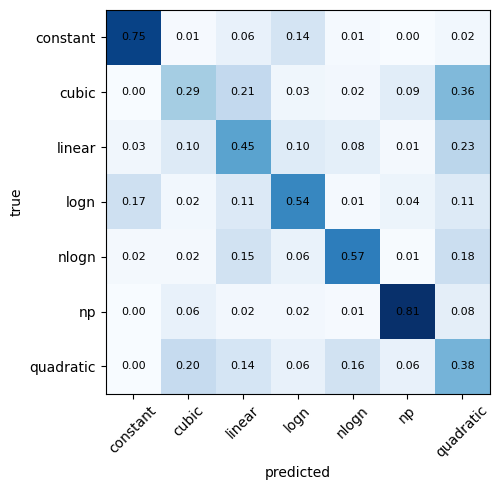

In [12]:
best = ExtraTreesClassifier(400, max_depth=15, random_state=0, n_jobs=-1)
pred = np.zeros_like(y)
for tr, te in prob_folds:
    best.fit(X[tr], y[tr])
    pred[te] = best.predict(X[te])
print(classification_report(y, pred, target_names=le.classes_))
cm = confusion_matrix(y, pred, normalize="true")
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(7), le.classes_, rotation=45)
plt.yticks(range(7), le.classes_)
for i in range(7):
    for j in range(7):
        plt.text(j, i, "%.2f" % cm[i, j], ha="center", va="center", fontsize=8)
plt.xlabel("predicted"); plt.ylabel("true")
plt.tight_layout()
plt.savefig("results/confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

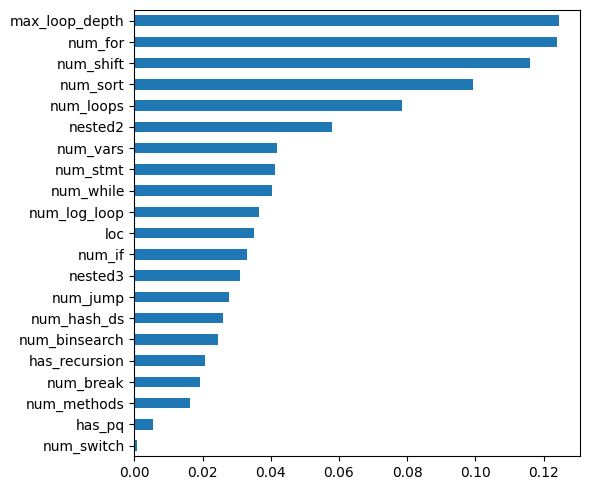

In [13]:
best.fit(X, y)
imp = pd.Series(best.feature_importances_, index=names).sort_values()
plt.figure(figsize=(6, 5))
imp.plot.barh()
plt.tight_layout()
plt.savefig("results/feature_importance.png", dpi=150)
plt.show()
pickle.dump(best, open("et_model.pkl", "wb"))

In [14]:
!zip -r results.zip results

  adding: results/ (stored 0%)
  adding: results/confusion_matrix.png (deflated 10%)
  adding: results/model_comparison.png (deflated 17%)
  adding: results/single_feature_accuracy.csv (deflated 40%)
  adding: results/feature_importance.png (deflated 22%)
  adding: results/model_comparison.csv (deflated 26%)


In [15]:
from google.colab import files
files.download("results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>